# Arabic GSM8K — Overthinking Study (v5, all discussion notes covered)

This notebook edits the previous Arabic pipeline based on the research-methodology discussion. The main changes are:

1. **Dataset integrity**: separate K-sweep validation and final test sets, with no ID overlap.
2. **Difficulty split**: difficulty is assigned from the **gold-solution reasoning steps**, not Arabic question length.
3. **Strict vs relaxed accuracy**: strict scoring accepts only `#### <number>`; relaxed scoring allows fallback extraction and reports fallback rate.
4. **Arabic-specific methods**: adds a format-controlled Arabic CoT method and keeps LOPR as the Arabic-problem / English-reasoning condition.
5. **K naming**: `K=1` is labeled as stochastic CoT or single-candidate verification, not full self-consistency / multi-candidate verification.
6. **CTE confidence parsing**: confidence must appear on its own line as `CONFIDENCE: High` or `CONFIDENCE: Low`.
7. **CTE calibration**: final analysis reports trusted vs escalated paths, accuracy, tokens, and calls.
8. **Raw response logging**: every response from every method is saved, including all SC/Verification samples, not only failures.
9. **Cache auditability**: cache files remain hashed for reuse, while response logs store method, problem ID, prompt version, sample index, prompt, response, tokens, and extraction status.
10. **Paired statistics**: McNemar exact test and paired bootstrap CIs are added for method comparisons against CoT.

Recommended run order:

1. Run setup and utility cells.
2. Run K-sweep on validation split.
3. Run final evaluation on the separate final test split.
4. Run final analysis, plots, CTE calibration, and pairwise statistics.


## Audit scope in this version
This version explicitly implements the notes discussed during review:
- strict CTE confidence parsing;
- strict vs relaxed answer extraction;
- fallback-rate logging;
- K-sweep with K=1 only as a reference;
- final Self-Consistency and Verification forced to K>1;
- validation/final-test non-overlap;
- gold-solution-step difficulty instead of Arabic word-count difficulty;
- readable dataset manifest with problem IDs, hashes, and number signatures;
- duplicate/overlap integrity checks;
- API caching and full raw-response logging;
- failure logging for all wrong/unparseable outputs;
- CTE calibration;
- Wilson, bootstrap, and McNemar paired statistics;
- Pareto and K-sweep figures.


In [1]:

"""
Setup, configuration, API client with disk caching, and output paths.
"""
import os
import re
import time
import json
import math
import hashlib
import random
from collections import Counter, defaultdict
from typing import Optional, Any

import numpy as np
import pandas as pd
from tqdm import tqdm
from openai import OpenAI
from datasets import load_dataset

# Kaggle-specific; falls back to environment variable outside Kaggle.
try:
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    NVIDIA_API_KEY = secrets.get_secret("NVIDIA_API_KEY")
except Exception:
    NVIDIA_API_KEY = os.environ.get("NVIDIA_API_KEY", "")

# ── Config ────────────────────────────────────────────────────────
MODEL          = "openai/gpt-oss-20b"
TOP_P          = 1.0
DATASET_ID     = "Omartificial-Intelligence-Space/Arabic-gsm8k"
DATASET_SPLIT  = "main_test"
SAFE_RPM       = 30
SEED           = 42

# Main final test set. Keep 100 for cost control; increase later if credits allow.
N_EASY, N_MEDIUM, N_HARD = 34, 33, 33

# K-sweep validation set. This set is excluded from final testing.
# Recommended: 50 if budget allows. Set to 30 for a cheap pilot.
N_KSWEEP_EASY, N_KSWEEP_MEDIUM, N_KSWEEP_HARD = 17, 17, 16
K_SWEEP_VALUES = [1, 2, 4, 8, 16]

# CTE: if the SC elbow is K=1, still use at least 3 total samples on escalation,
# otherwise CTE would not really escalate.
MIN_CTE_ESCALATION_TOTAL_SAMPLES = 3

# Prompt version lock: change only on validation; freeze before final test.
PROMPT_VERSION = "v5_locked_after_validation"

# Output paths
RUN_DIR = "./arabic_gsm8k_v5_outputs"
CACHE_DIR = os.path.join(RUN_DIR, "api_cache")
os.makedirs(CACHE_DIR, exist_ok=True)

FAILURE_LOG          = os.path.join(RUN_DIR, "failures.jsonl")
ALL_RESPONSES_LOG    = os.path.join(RUN_DIR, "all_raw_responses.jsonl")
EVAL_RECORDS_CSV     = os.path.join(RUN_DIR, "per_problem_eval_records.csv")
RESULTS_CSV          = os.path.join(RUN_DIR, "results_arabic_gsm8k_v5.csv")
KSWEEP_CSV           = os.path.join(RUN_DIR, "ksweep_results.csv")
KSWEEP_PLOT          = os.path.join(RUN_DIR, "ksweep_pareto_curve.png")
METHODS_PARETO_PLOT  = os.path.join(RUN_DIR, "methods_pareto.png")
SAMPLE_MANIFEST_CSV  = os.path.join(RUN_DIR, "sample_manifest.csv")
CTE_CALIBRATION_CSV  = os.path.join(RUN_DIR, "cte_calibration.csv")
PAIRWISE_STATS_CSV   = os.path.join(RUN_DIR, "pairwise_stats_vs_cot.csv")

random.seed(SEED)
np.random.seed(SEED)

# Clear analysis logs on fresh run. Cache is intentionally NOT cleared.
for p in [FAILURE_LOG, ALL_RESPONSES_LOG]:
    if os.path.exists(p):
        os.remove(p)

# ── API client ────────────────────────────────────────────────────
client = OpenAI(base_url="https://integrate.api.nvidia.com/v1", api_key=NVIDIA_API_KEY)

class RateLimiter:
    def __init__(self, max_per_min=SAFE_RPM):
        self.interval  = 60.0 / max_per_min
        self.last_call = 0.0

    def wait(self):
        gap = self.interval - (time.time() - self.last_call)
        if gap > 0:
            time.sleep(gap)
        self.last_call = time.time()

limiter = RateLimiter()

def _cache_key(prompt: str, temperature: float, max_tokens: int, sample_idx: int,
               cache_scope: str = "global") -> str:
    """
    Disk cache key. The cache_scope is normally the method/call role.
    This prevents accidental cross-method reuse when two methods share a prompt.
    The prompt itself contains the problem text, and sample_idx separates stochastic samples.
    """
    payload = f"{MODEL}|scope={cache_scope}|{prompt}|t={temperature}|top_p={TOP_P}|mt={max_tokens}|s={sample_idx}"
    h = hashlib.sha256(payload.encode("utf-8")).hexdigest()
    return os.path.join(CACHE_DIR, f"{h}.json")

def call_api(prompt: str, temperature: float = 0.0, max_tokens: int = 1500,
             sample_idx: int = 0, cache_scope: str = "global") -> tuple[str, int, int, bool, str]:
    """
    Call NVIDIA API with disk caching.

    Returns:
        response_text, input_tokens, output_tokens, cache_hit, cache_path
    """
    cache_path = _cache_key(prompt, temperature, max_tokens, sample_idx, cache_scope=cache_scope)
    if os.path.exists(cache_path):
        try:
            with open(cache_path, "r", encoding="utf-8") as f:
                d = json.load(f)
            return d["text"], d["in_tokens"], d["out_tokens"], True, cache_path
        except Exception:
            pass  # corrupt cache entry, refetch

    limiter.wait()
    try:
        comp = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=max(temperature, 1e-6),
            max_tokens=max_tokens,
            top_p=TOP_P,
        )
        msg = comp.choices[0].message.content or ""
        in_t  = comp.usage.prompt_tokens     if comp.usage else len(prompt) // 4
        out_t = comp.usage.completion_tokens if comp.usage else len(msg) // 4
    except Exception as e:
        print(f"  ⚠ API error: {e}")
        return "", 0, 0, False, cache_path

    with open(cache_path, "w", encoding="utf-8") as f:
        json.dump({
            "text": msg,
            "in_tokens": in_t,
            "out_tokens": out_t,
            "prompt": prompt,
            "temperature": temperature,
            "max_tokens": max_tokens,
            "sample_idx": sample_idx,
            "cache_scope": cache_scope,
            "top_p": TOP_P,
            "model": MODEL,
        }, f, ensure_ascii=False, indent=2)

    return msg, in_t, out_t, False, cache_path

print("Setup complete.")
print("Model:", MODEL)
print("Top-p:", TOP_P)
print("Run directory:", RUN_DIR)
print("Cache entries:", len(os.listdir(CACHE_DIR)))


Setup complete.
Model: openai/gpt-oss-20b
Top-p: 1.0
Run directory: ./arabic_gsm8k_v5_outputs
Cache entries: 0


In [2]:

"""
Arabic numeral normalization, strict/relaxed answer extraction,
statistics, and JSONL logging utilities.
"""

# ── Arabic numeral normalization ──────────────────────────────────
EASTERN_TO_WESTERN = str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789")

def normalize_arabic_numerals(text: str) -> str:
    return text.translate(EASTERN_TO_WESTERN) if text else text

def safe_float(s: str) -> Optional[float]:
    try:
        return float(str(s).replace(",", "").strip().rstrip("."))
    except Exception:
        return None

NUM_RE = r"[-+]?\d+(?:,\d{3})*(?:\.\d+)?"
STRICT_FINAL_RE = re.compile(rf"(?m)^\s*####\s*({NUM_RE})\s*$")
ANY_HASH_FINAL_RE = re.compile(rf"####\s*({NUM_RE})")

def extract_answer_strict(text: str) -> Optional[float]:
    """Strict parser: accepts only an explicit #### marker."""
    if not text:
        return None
    text = normalize_arabic_numerals(text)
    m = STRICT_FINAL_RE.search(text)
    if not m:
        m = ANY_HASH_FINAL_RE.search(text)
    return safe_float(m.group(1)) if m else None

def extract_answer_relaxed(text: str) -> tuple[Optional[float], bool]:
    """
    Relaxed parser: first tries strict #### parsing, then falls back to the
    last number in the text. used_fallback=True means the answer was not in
    the required final format.
    """
    strict = extract_answer_strict(text)
    if strict is not None:
        return strict, False
    if not text:
        return None, False
    text = normalize_arabic_numerals(text)
    nums = re.findall(NUM_RE, text)
    if nums:
        return safe_float(nums[-1]), True
    return None, False

# Backward-compatible name: relaxed extraction.
def extract_answer(text: str) -> tuple[Optional[float], bool]:
    return extract_answer_relaxed(text)

def extract_gold_answer(answer_text: str) -> Optional[float]:
    """Gold answers usually contain ####; fallback is acceptable for labels only."""
    strict = extract_answer_strict(str(answer_text))
    if strict is not None:
        return strict
    relaxed, _ = extract_answer_relaxed(str(answer_text))
    return relaxed

def parse_model_answer(text: str) -> dict:
    strict = extract_answer_strict(text)
    relaxed, used_fallback = extract_answer_relaxed(text)
    return {
        "pred_strict": strict,
        "pred_relaxed": relaxed,
        "used_fallback": bool(used_fallback),
    }

def answers_match(pred, gold) -> bool:
    if pred is None or gold is None:
        return False
    try:
        return abs(float(pred) - float(gold)) < 1e-3
    except Exception:
        return False


# ── Dataset integrity helpers ────────────────────────────────────
def normalize_problem_text(text: str) -> str:
    """Language-local normalized text hash: catches exact/near-exact duplicates within the same language."""
    text = normalize_arabic_numerals(str(text).lower())
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s\d]", "", text, flags=re.UNICODE)
    return text.strip()

def problem_text_hash(text: str) -> str:
    return hashlib.md5(normalize_problem_text(text).encode("utf-8")).hexdigest()

def number_signature(text: str) -> str:
    """Number sequence proxy. Useful for detecting translated or duplicated math problems."""
    text = normalize_arabic_numerals(str(text))
    nums = re.findall(NUM_RE, text)
    return "|".join(nums)

# ── Reasoning-step and difficulty utilities ───────────────────────
def count_steps(text: str) -> int:
    """Output reasoning steps. For model response diagnostics only."""
    if not text:
        return 1
    steps = re.findall(r"<<[^>]+>>", text)
    return len(steps) if steps else max(1, text.count("\n"))

def count_gold_solution_steps(answer_text: str) -> int:
    """
    Difficulty proxy based on gold-solution reasoning steps, not question length.
    Priority:
      1. GSM8K-style <<calculation>> markers
      2. arithmetic operator count
      3. fallback = 1 step
    """
    answer_text = normalize_arabic_numerals(str(answer_text))
    calc_markers = re.findall(r"<<[^>]+>>", answer_text)
    if calc_markers:
        return len(calc_markers)
    # Count arithmetic signs in the gold explanation, excluding the final #### marker.
    text_wo_final = re.sub(r"####.*", "", answer_text)
    ops = re.findall(r"[+\-*/=]", text_wo_final)
    return max(1, len(ops))

def assign_difficulty_from_gold(answer_text: str) -> str:
    steps = count_gold_solution_steps(answer_text)
    if steps <= 2:
        return "Easy"
    elif steps <= 4:
        return "Medium"
    return "Hard"

# ── Statistical utilities ─────────────────────────────────────────
def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half   = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))

def bootstrap_ci(values: list, n_boot: int = 2000, seed: int = SEED) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    n = len(values)
    if n == 0:
        return (0.0, 0.0)
    arr = np.asarray(values, dtype=float)
    means = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[i] = arr[idx].mean()
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))

def paired_bootstrap_diff(a: list[int], b: list[int], n_boot: int = 5000,
                          seed: int = SEED) -> tuple[float, float, float]:
    """Bootstrap CI for mean(b - a), paired by question."""
    assert len(a) == len(b)
    rng = np.random.default_rng(seed)
    arr_a = np.asarray(a, dtype=float)
    arr_b = np.asarray(b, dtype=float)
    n = len(arr_a)
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        diffs[i] = (arr_b[idx] - arr_a[idx]).mean()
    return float((arr_b - arr_a).mean()), float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

def mcnemar_exact_p(a: list[int], b: list[int]) -> tuple[int, int, float]:
    """
    Exact two-sided McNemar binomial test for paired binary correctness.
    Returns b01, b10, p where:
      b01 = baseline wrong, method correct
      b10 = baseline correct, method wrong
    """
    assert len(a) == len(b)
    b01 = sum((x == 0 and y == 1) for x, y in zip(a, b))
    b10 = sum((x == 1 and y == 0) for x, y in zip(a, b))
    n = b01 + b10
    if n == 0:
        return b01, b10, 1.0
    k = min(b01, b10)
    # exact two-sided binomial p-value under p=0.5
    p_one_tail = sum(math.comb(n, i) * (0.5 ** n) for i in range(k + 1))
    return b01, b10, min(1.0, 2 * p_one_tail)

# ── JSONL logging ─────────────────────────────────────────────────
def append_jsonl(path: str, rec: dict):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")


def automatic_failure_category(gold, pred_strict, pred_relaxed, responses: list[dict],
                               strict_correct: bool, relaxed_correct: bool) -> str:
    """
    Lightweight automatic label for later manual error analysis.
    Final paper categories should still be manually verified on the failure JSONL.
    """
    if strict_correct:
        return "not_failure_strict"
    if pred_strict is None and relaxed_correct:
        return "format_or_extraction_failure_strict_only"
    if pred_strict is None and pred_relaxed is None:
        return "unparseable_no_numeric_answer"
    if any(r.get("used_fallback") for r in responses):
        return "fallback_used_wrong_or_unreliable"
    # Answer flip proxy: a correct relaxed/strict number appears in an earlier response but final selected answer is wrong.
    try:
        g = float(gold)
        for r in responses:
            txt = normalize_arabic_numerals(r.get("response", ""))
            nums = [safe_float(x) for x in re.findall(NUM_RE, txt)]
            if any(x is not None and abs(float(x) - g) < 1e-3 for x in nums):
                return "possible_answer_flip_or_verification_failure"
    except Exception:
        pass
    return "reasoning_or_arithmetic_error_manual_review_needed"

def log_failure(method: str, item: dict, gold, pred_strict, pred_relaxed,
                responses: list[dict], strict_correct: bool, relaxed_correct: bool):
    """Append one wrong/unparseable problem to JSONL for paper error analysis."""
    rec = {
        "method": method,
        "problem_id": item["problem_id"],
        "split": item.get("split", "final_test"),
        "question": item["question_ar"],
        "gold": gold,
        "pred_strict": pred_strict,
        "pred_relaxed": pred_relaxed,
        "difficulty": item["difficulty"],
        "gold_steps": item.get("gold_steps"),
        "strict_correct": strict_correct,
        "relaxed_correct": relaxed_correct,
        "dataset": item.get("dataset"),
        "dataset_split": item.get("dataset_split"),
        "language": item.get("language", "ar"),
        "question_hash": item.get("question_hash"),
        "number_signature": item.get("number_signature"),
        "responses": responses,
        "failure_category_auto": automatic_failure_category(
            gold, pred_strict, pred_relaxed, responses, strict_correct, relaxed_correct
        ),
        "manual_error_category": "TODO_manual_review",
    }
    append_jsonl(FAILURE_LOG, rec)

print("Utilities loaded.")


Utilities loaded.


In [3]:

"""
Dataset integrity and stratified sampling.
Difficulty is based on gold-solution steps, not Arabic word count.
Validation/K-sweep and final test samples are non-overlapping by problem_id.
"""

def item_to_record(idx: int, item: dict, split: str = "unassigned") -> dict:
    gold_steps = count_gold_solution_steps(item["answer"])
    return {
        "problem_id": idx,
        "original_problem_id": item.get("id", idx) if isinstance(item, dict) else idx,
        "dataset": DATASET_ID,
        "dataset_source": DATASET_ID,
        "dataset_split": DATASET_SPLIT,
        "language": "ar",
        "question_ar": item["question"],
        "question_hash": problem_text_hash(item["question"]),
        "number_signature": number_signature(item["question"]),
        "answer": item["answer"],
        "gold_answer": extract_gold_answer(item["answer"]),
        "gold_steps": gold_steps,
        "difficulty": assign_difficulty_from_gold(item["answer"]),
        "split": split,
    }

def build_buckets(dataset, held_out_ids: set | None = None, split: str = "unassigned") -> dict[str, list[dict]]:
    held_out_ids = held_out_ids or set()
    buckets = {"Easy": [], "Medium": [], "Hard": []}
    for idx, item in enumerate(dataset):
        if idx in held_out_ids:
            continue
        rec = item_to_record(idx, item, split=split)
        buckets[rec["difficulty"]].append(rec)
    return buckets

def _sample_bucket(buckets: dict[str, list[dict]], difficulty: str, n: int) -> list[dict]:
    available = len(buckets[difficulty])
    if available < n:
        raise ValueError(f"Not enough {difficulty} samples: requested {n}, available {available}")
    return random.sample(buckets[difficulty], n)

def stratified_sample(dataset, n_easy: int, n_medium: int, n_hard: int,
                      held_out_ids: set | None = None, split: str = "final_test") -> list[dict]:
    buckets = build_buckets(dataset, held_out_ids=held_out_ids, split=split)
    print(f"Available after held-out exclusion -> Easy: {len(buckets['Easy'])} | "
          f"Medium: {len(buckets['Medium'])} | Hard: {len(buckets['Hard'])}")
    samples = []
    samples.extend(_sample_bucket(buckets, "Easy", n_easy))
    samples.extend(_sample_bucket(buckets, "Medium", n_medium))
    samples.extend(_sample_bucket(buckets, "Hard", n_hard))
    random.shuffle(samples)
    return samples

def assert_no_overlap(a: list[dict], b: list[dict], name_a="A", name_b="B"):
    ids_a = {x["problem_id"] for x in a}
    ids_b = {x["problem_id"] for x in b}
    overlap = ids_a & ids_b
    if overlap:
        raise AssertionError(f"Overlap between {name_a} and {name_b}: {sorted(list(overlap))[:10]}")
    print(f"✓ No overlap between {name_a} and {name_b} ({len(ids_a)} vs {len(ids_b)} samples).")


def assert_no_duplicate_questions(samples: list[dict], name="sample set"):
    """Check normalized same-language duplicate questions inside one sample set."""
    seen = {}
    duplicates = []
    for s in samples:
        h = s.get("question_hash")
        if h in seen:
            duplicates.append((seen[h], s["problem_id"]))
        else:
            seen[h] = s["problem_id"]
    if duplicates:
        raise AssertionError(f"Duplicate normalized questions in {name}: {duplicates[:10]}")
    print(f"✓ No normalized duplicate questions inside {name}.")

def report_number_signature_overlap(a: list[dict], b: list[dict], name_a="A", name_b="B"):
    """
    Soft check: same number sequence across splits can indicate related/translated problems.
    It is not automatically an error, but it should be reviewed and reported.
    """
    sig_a = defaultdict(list)
    sig_b = defaultdict(list)
    for x in a:
        if x.get("number_signature"):
            sig_a[x["number_signature"]].append(x["problem_id"])
    for x in b:
        if x.get("number_signature"):
            sig_b[x["number_signature"]].append(x["problem_id"])
    overlap = sorted(set(sig_a) & set(sig_b))
    print(f"Number-signature overlap between {name_a} and {name_b}: {len(overlap)} signatures")
    if overlap[:5]:
        print("  Review examples:", [(sig, sig_a[sig][:3], sig_b[sig][:3]) for sig in overlap[:5]])
    return overlap

def save_sample_manifest(*sample_lists: list[dict]):
    rows = []
    for samples in sample_lists:
        for s in samples:
            rows.append({
                "problem_id": s["problem_id"],
                "original_problem_id": s.get("original_problem_id"),
                "dataset": s["dataset"],
                "dataset_source": s.get("dataset_source", s["dataset"]),
                "dataset_split": s["dataset_split"],
                "language": s["language"],
                "split": s["split"],
                "difficulty": s["difficulty"],
                "gold_steps": s["gold_steps"],
                "gold_answer": s["gold_answer"],
                "question_hash": s.get("question_hash"),
                "number_signature": s.get("number_signature"),
            })
    df = pd.DataFrame(rows).sort_values(["split", "difficulty", "problem_id"])
    df.to_csv(SAMPLE_MANIFEST_CSV, index=False)
    print(f"✓ Saved sample manifest: {SAMPLE_MANIFEST_CSV}")
    return df

print("Sampling functions loaded.")


Sampling functions loaded.


In [4]:

"""
Prompt methods. Each returns the same schema:
    pred_strict, pred_relaxed, calls, tokens, steps, fallbacks, responses, metadata

All raw responses are returned so the evaluator can log every sample for auditability.
"""

def make_response_record(call_role: str, prompt: str, text: str, in_t: int, out_t: int,
                         temperature: float, max_tokens: int, sample_idx: int,
                         cache_hit: bool, cache_path: str) -> dict:
    parsed = parse_model_answer(text)
    return {
        "call_role": call_role,
        "sample_idx": sample_idx,
        "temperature": temperature,
        "max_tokens": max_tokens,
        "top_p": TOP_P,
        "input_tokens": in_t,
        "output_tokens": out_t,
        "total_tokens": in_t + out_t,
        "cache_hit": cache_hit,
        "cache_path": cache_path,
        "prompt": prompt,
        "response": text,
        "pred_strict": parsed["pred_strict"],
        "pred_relaxed": parsed["pred_relaxed"],
        "used_fallback": parsed["used_fallback"],
        "steps": count_steps(text),
    }

def api_response(call_role: str, prompt: str, temperature: float = 0.0,
                 max_tokens: int = 1500, sample_idx: int = 0) -> dict:
    text, in_t, out_t, cache_hit, cache_path = call_api(
        prompt, temperature=temperature, max_tokens=max_tokens,
        sample_idx=sample_idx, cache_scope=call_role
    )
    return make_response_record(call_role, prompt, text, in_t, out_t, temperature,
                                max_tokens, sample_idx, cache_hit, cache_path)

def mode_or_none(values: list[Optional[float]]) -> Optional[float]:
    vals = [v for v in values if v is not None]
    return Counter(vals).most_common(1)[0][0] if vals else None

def package_result(pred_strict, pred_relaxed, responses: list[dict], metadata: dict | None = None) -> dict:
    metadata = metadata or {}
    calls = len(responses)
    tokens = sum(r["total_tokens"] for r in responses)
    steps = np.mean([r["steps"] for r in responses]) if responses else 0
    fallbacks = sum(int(r["used_fallback"]) for r in responses)
    return {
        "pred": pred_relaxed,  # backward-compatible relaxed prediction
        "pred_strict": pred_strict,
        "pred_relaxed": pred_relaxed,
        "calls": calls,
        "tokens": tokens,
        "steps": float(steps),
        "fallbacks": fallbacks,
        "responses": responses,
        "metadata": metadata,
    }

# ── 1. Direct Arabic ──────────────────────────────────────────────
def run_direct(item: dict) -> dict:
    prompt = (
        "حل هذه المسألة الرياضية. أجب فقط بالرقم النهائي بهذا الشكل بالضبط:\n"
        "#### <number>\n\n"
        f"المسألة: {item['question_ar']}\n\n"
        "الإجابة:"
    )
    r = api_response("direct", prompt, max_tokens=120)
    return package_result(r["pred_strict"], r["pred_relaxed"], [r])

# ── 2. Arabic CoT ─────────────────────────────────────────────────
def run_cot(item: dict) -> dict:
    prompt = (
        "حل هذه المسألة الرياضية خطوة بخطوة باللغة العربية الفصحى.\n"
        "في النهاية اكتب الإجابة النهائية بهذا الشكل فقط:\n"
        "#### <number>\n\n"
        f"المسألة: {item['question_ar']}\n\n"
        "الحل:"
    )
    r = api_response("cot", prompt)
    return package_result(r["pred_strict"], r["pred_relaxed"], [r])

# ── 3. Format-controlled Arabic CoT ───────────────────────────────
def run_cot_format_controlled(item: dict) -> dict:
    prompt = (
        "حل المسألة خطوة بخطوة باللغة العربية الفصحى.\n\n"
        "تعليمات مهمة للتنسيق والأرقام:\n"
        "- لا تستخدم لهجة عامية.\n"
        "- استخدم الأرقام القياسية فقط: 0 1 2 3 4 5 6 7 8 9.\n"
        "- لا تكتب الإجابة النهائية بالكلمات.\n"
        "- لا تكتب أي رقم بعد سطر الإجابة النهائية.\n"
        "- يجب أن يكون آخر سطر في الرد بهذا الشكل بالضبط:\n"
        "#### <number>\n\n"
        f"المسألة: {item['question_ar']}\n\n"
        "الحل:"
    )
    r = api_response("cot_format_controlled", prompt)
    return package_result(r["pred_strict"], r["pred_relaxed"], [r])

# ── 4. Self-Consistency / stochastic CoT ──────────────────────────
def run_sc(item: dict, k: int = 4) -> dict:
    prompt = (
        "حل هذه المسألة الرياضية خطوة بخطوة باللغة العربية الفصحى.\n"
        "في النهاية اكتب الإجابة النهائية بهذا الشكل فقط:\n"
        "#### <number>\n\n"
        f"المسألة: {item['question_ar']}\n\n"
        "الحل:"
    )
    responses = []
    for s in range(k):
        responses.append(api_response("sc_sample", prompt, temperature=0.7, sample_idx=s))
    pred_strict = mode_or_none([r["pred_strict"] for r in responses])
    pred_relaxed = mode_or_none([r["pred_relaxed"] for r in responses])
    return package_result(pred_strict, pred_relaxed, responses, metadata={"k": k})

# ── 5. Verification ───────────────────────────────────────────────
def run_verification(item: dict, k: int = 4) -> dict:
    gen_prompt = (
        "حل المسألة خطوة بخطوة باللغة العربية الفصحى.\n"
        "في النهاية اكتب الإجابة النهائية بهذا الشكل فقط:\n"
        "#### <number>\n\n"
        f"المسألة: {item['question_ar']}\n\n"
        "الحل:"
    )
    responses = []
    candidates = []
    for s in range(k):
        r = api_response("verification_candidate", gen_prompt, temperature=0.7, sample_idx=s)
        responses.append(r)
        # Prefer strict candidates; use relaxed only if strict missing, and record fallback in response.
        cand = r["pred_strict"] if r["pred_strict"] is not None else r["pred_relaxed"]
        if cand is not None:
            candidates.append(str(cand))

    if not candidates:
        return package_result(None, None, responses, metadata={"k": k, "candidate_count": 0})

    ver_prompt = (
        f"المسألة: {item['question_ar']}\n\n"
        f"الحلول المقترحة: {', '.join(candidates)}\n\n"
        "اختر الحل الصحيح فقط بعد التحقق من الحساب.\n"
        "اكتب الإجابة النهائية في آخر سطر بهذا الشكل بالضبط:\n"
        "#### <number>"
    )
    v = api_response("verification_judge", ver_prompt, temperature=0.0, sample_idx=10_000 + k)
    responses.append(v)
    return package_result(v["pred_strict"], v["pred_relaxed"], responses,
                          metadata={"k": k, "candidate_count": len(candidates)})

# ── 6. Arabic FAA ─────────────────────────────────────────────────
def run_faa(item: dict) -> dict:
    prompt = (
        "حل هذه المسألة.\n\n"
        "أولاً، اكتب إجابتك الأولية مباشرة بهذا الشكل قبل أي شرح:\n"
        "#### <number>\n\n"
        "بعد ذلك، اشرح الحل خطوة بخطوة باختصار.\n"
        "لا تغيّر الإجابة الأولية إلا إذا وجدت خطأ حسابياً واضحاً.\n"
        "يجب أن يكون آخر سطر أيضاً بهذا الشكل:\n"
        "#### <number>\n\n"
        f"المسألة: {item['question_ar']}\n\n"
        "الإجابة والحل:"
    )
    r = api_response("faa", prompt, max_tokens=1000)
    return package_result(r["pred_strict"], r["pred_relaxed"], [r])

# ── 7. Arabic CTE ─────────────────────────────────────────────────
# Confidence must appear on its own line. This avoids substring false positives.
CTE_CONF_RE = re.compile(
    r"^\s*CONFIDENCE\s*:\s*(High|Low)\s*$",
    re.IGNORECASE | re.MULTILINE
)

def _parse_confidence(text: str) -> Optional[str]:
    if not text:
        return None
    m = CTE_CONF_RE.search(text)
    if not m:
        return None
    return "High" if m.group(1).lower() == "high" else "Low"

def run_cte(item: dict, escalate_extra: int = 2) -> dict:
    prompt = (
        "حل المسألة خطوة بخطوة باللغة العربية الفصحى.\n"
        "في النهاية اكتب سطرين فقط بهذا الشكل:\n\n"
        "#### <number>\n"
        "CONFIDENCE: High\n\n"
        "أو:\n\n"
        "#### <number>\n"
        "CONFIDENCE: Low\n\n"
        "استخدم High فقط إذا كنت متأكداً من الفهم والحساب.\n"
        "استخدم Low إذا كان هناك أي شك في الفهم أو الحساب.\n\n"
        f"المسألة: {item['question_ar']}\n\n"
        "الحل:"
    )
    responses = [api_response("cte_initial", prompt, temperature=0.0, sample_idx=0)]
    conf = _parse_confidence(responses[0]["response"])

    if conf == "High":
        return package_result(
            responses[0]["pred_strict"], responses[0]["pred_relaxed"], responses,
            metadata={"confidence": conf, "cte_path": "trusted_high", "escalate_extra": 0}
        )

    # Explicit Low or missing confidence => escalate.
    for s in range(escalate_extra):
        responses.append(api_response("cte_escalation_sample", prompt, temperature=0.7, sample_idx=100 + s))

    pred_strict = mode_or_none([r["pred_strict"] for r in responses])
    pred_relaxed = mode_or_none([r["pred_relaxed"] for r in responses])
    path = "escalated_low" if conf == "Low" else "escalated_missing_confidence"
    return package_result(pred_strict, pred_relaxed, responses,
                          metadata={"confidence": conf, "cte_path": path,
                                    "escalate_extra": escalate_extra})

# ── 8. LOPR: Arabic problem, English reasoning ────────────────────
def run_lopr(item: dict) -> dict:
    prompt = (
        "You will be given a math word problem written in Arabic.\n"
        "First, understand the Arabic problem carefully.\n"
        "Then solve it step by step IN ENGLISH. Preserve all numbers, units, and relationships exactly.\n"
        "At the end, output the final numeric answer on its own line in this exact format:\n"
        "#### <number>\n\n"
        f"Arabic problem:\n{item['question_ar']}\n\n"
        "Step-by-step reasoning in English:"
    )
    r = api_response("lopr_en_reasoning", prompt)
    return package_result(r["pred_strict"], r["pred_relaxed"], [r])

# Registry is rebuilt after K-sweep because K_SC/K_VERIF are chosen there.
def method_display_name_sc(k: int) -> str:
    return f"Stochastic CoT K=1" if k == 1 else f"Self-Consistency K={k}"

def method_display_name_verification(k: int) -> str:
    return f"Single-Candidate Verification K=1" if k == 1 else f"Multi-Candidate Verification K={k}"

print("Prompt methods loaded.")


Prompt methods loaded.


Loading dataset for K-sweep...


README.md: 0.00B [00:00, ?B/s]

data/main_train-00000-of-00001.parquet:   0%|          | 0.00/2.94M [00:00<?, ?B/s]

data/main_test-00000-of-00001.parquet:   0%|          | 0.00/533k [00:00<?, ?B/s]

data/socratic_train-00000-of-00001.parqu(…):   0%|          | 0.00/3.43M [00:00<?, ?B/s]

...

  Strict Acc: 0.860 [0.738, 0.930] | Relaxed Acc: 0.860 | Tok/Q: 3208 | Calls/Q: 5.00

── Multi-Candidate Verification K=8 ──


Multi-Candidate Verification K=8: 100%|██████████| 50/50 [09:43<00:00, 11.67s/it]


  Strict Acc: 0.860 [0.738, 0.930] | Relaxed Acc: 0.860 | Tok/Q: 5875 | Calls/Q: 9.00

── Multi-Candidate Verification K=16 ──


Multi-Candidate Verification K=16: 100%|██████████| 50/50 [21:27<00:00, 25.75s/it]


  Strict Acc: 0.880 [0.762, 0.944] | Relaxed Acc: 0.880 | Tok/Q: 11271 | Calls/Q: 17.00

K-SWEEP RESULTS
method_family                    display_method  k  n  correct_strict  accuracy_strict  accuracy_relaxed  ci_low  ci_high  tokens_per_q  calls_per_q  fail_rate_strict  fallback_rate_per_call
           SC                Stochastic CoT K=1  1 50              44             0.88              0.88  0.7619   0.9438         633.5         1.00              0.00                  0.0000
           SC              Self-Consistency K=2  2 50              44             0.88              0.88  0.7619   0.9438        1223.5         2.00              0.00                  0.0100
           SC              Self-Consistency K=4  4 50              46             0.92              0.92  0.8116   0.9685        2386.6         4.00              0.00                  0.0050
           SC              Self-Consistency K=8  8 50              45             0.90              0.90  0.7864   0.9565        48

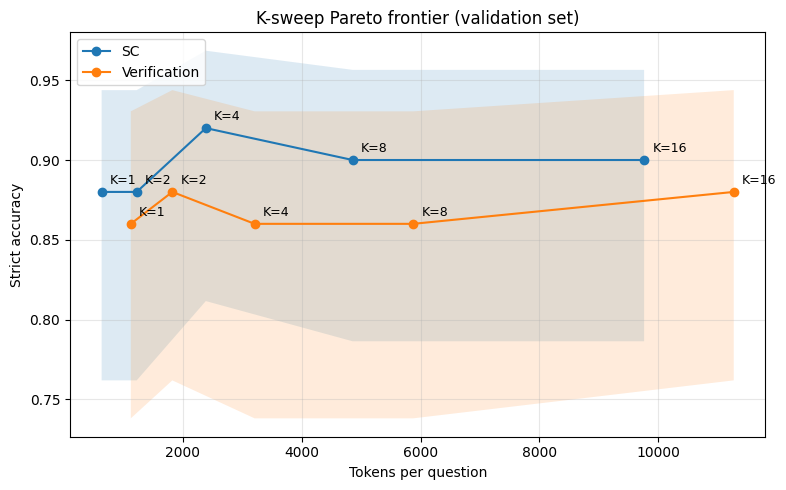

✓ Saved: ./arabic_gsm8k_v5_outputs/ksweep_pareto_curve.png


In [5]:

"""
K-sweep experiment on a validation split.
K=1 is a reference point, not full self-consistency.
"""

import matplotlib.pyplot as plt

print("Loading dataset for K-sweep...")
_ds_full = load_dataset(DATASET_ID, split=DATASET_SPLIT)

_kweep_samples = stratified_sample(
    _ds_full,
    N_KSWEEP_EASY, N_KSWEEP_MEDIUM, N_KSWEEP_HARD,
    held_out_ids=set(),
    split="ksweep_validation"
)
_kweep_ids = {s["problem_id"] for s in _kweep_samples}
print(f"K-sweep validation set: {len(_kweep_samples)} problems")

def run_k_sweep(val_samples: list[dict], k_values: list[int] = K_SWEEP_VALUES,
                methods: tuple[str, ...] = ("SC", "Verification")) -> pd.DataFrame:
    rows = []
    for method_name in methods:
        for k in k_values:
            display = method_display_name_sc(k) if method_name == "SC" else method_display_name_verification(k)
            print(f"\n── {display} ──")
            correct_strict, correct_relaxed, fails_strict = 0, 0, 0
            tokens_total, calls_total, fallbacks_total = 0, 0, 0
            for item in tqdm(val_samples, desc=display):
                res = run_sc(item, k=k) if method_name == "SC" else run_verification(item, k=k)
                gold = item["gold_answer"]
                if res["pred_strict"] is None:
                    fails_strict += 1
                if answers_match(res["pred_strict"], gold):
                    correct_strict += 1
                if answers_match(res["pred_relaxed"], gold):
                    correct_relaxed += 1
                tokens_total += res["tokens"]
                calls_total  += res["calls"]
                fallbacks_total += res["fallbacks"]

            n = len(val_samples)
            acc_s = correct_strict / n
            acc_r = correct_relaxed / n
            ci_lo, ci_hi = wilson_ci(correct_strict, n)
            rows.append({
                "method_family": method_name,
                "display_method": display,
                "k": k,
                "n": n,
                "correct_strict": correct_strict,
                "accuracy_strict": round(acc_s, 4),
                "accuracy_relaxed": round(acc_r, 4),
                "ci_low": round(ci_lo, 4),
                "ci_high": round(ci_hi, 4),
                "tokens_per_q": round(tokens_total / n, 1),
                "calls_per_q": round(calls_total / n, 2),
                "fail_rate_strict": round(fails_strict / n, 4),
                "fallback_rate_per_call": round(fallbacks_total / max(calls_total, 1), 4),
            })
            print(f"  Strict Acc: {acc_s:.3f} [{ci_lo:.3f}, {ci_hi:.3f}] | "
                  f"Relaxed Acc: {acc_r:.3f} | Tok/Q: {tokens_total / n:.0f} | Calls/Q: {calls_total / n:.2f}")
    return pd.DataFrame(rows)

def find_elbow(df_method: pd.DataFrame) -> int:
    """
    Pick the smallest K before marginal strict-accuracy gain per extra tokens collapses.
    If all gains are flat or negative, returns K=1, which is valid evidence that
    extra sampling is overthinking on this validation set.
    """
    df = df_method.sort_values("k").reset_index(drop=True)
    if len(df) < 2:
        return int(df["k"].iloc[0])
    for i in range(1, len(df)):
        d_acc = df["accuracy_strict"].iloc[i] - df["accuracy_strict"].iloc[i - 1]
        d_tok = df["tokens_per_q"].iloc[i] - df["tokens_per_q"].iloc[i - 1]
        gain_per_1k = (d_acc / d_tok) * 1000 if d_tok > 0 else 0
        # Less than 0.5 percentage points per additional 1000 tokens.
        if gain_per_1k < 0.005:
            return int(df["k"].iloc[i - 1])
    return int(df["k"].iloc[-1])

def plot_k_sweep_pareto(df: pd.DataFrame, save_path: str = KSWEEP_PLOT):
    fig, ax = plt.subplots(figsize=(8, 5))
    for family, sub in df.groupby("method_family"):
        sub = sub.sort_values("tokens_per_q")
        ax.plot(sub["tokens_per_q"], sub["accuracy_strict"], marker="o", label=family)
        for _, row in sub.iterrows():
            ax.annotate(f"K={int(row['k'])}",
                        (row["tokens_per_q"], row["accuracy_strict"]),
                        textcoords="offset points", xytext=(6, 6), fontsize=9)
        ax.fill_between(sub["tokens_per_q"], sub["ci_low"], sub["ci_high"], alpha=0.15)
    ax.set_xlabel("Tokens per question")
    ax.set_ylabel("Strict accuracy")
    ax.set_title("K-sweep Pareto frontier (validation set)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"✓ Saved: {save_path}")

ksweep_df = run_k_sweep(_kweep_samples)
ksweep_df.to_csv(KSWEEP_CSV, index=False)
print("\n" + "=" * 70)
print("K-SWEEP RESULTS")
print("=" * 70)
print(ksweep_df.to_string(index=False))

elbows = {}
for family, sub in ksweep_df.groupby("method_family"):
    k_star = find_elbow(sub)
    elbows[family] = k_star
    print(f"\nElbow K for {family}: K={k_star}")

plot_k_sweep_pareto(ksweep_df)


In [6]:

"""
Main evaluation on the stratified final test set.
The K-sweep validation set is excluded.
Reports strict and relaxed accuracy, difficulty-level accuracy, and logs all raw responses.
"""

# Use elbow K from sweep if available, otherwise default to 4.
# IMPORTANT FOR PAPER VALIDITY:
# K=1 is kept only as a reference point in the K-sweep.
# Final Self-Consistency and Verification must use K>1 because K=1 has no voting/comparison.
try:
    K_SC_RAW = int(elbows.get("SC", 4))
    K_VERIF_RAW = int(elbows.get("Verification", 4))
except NameError:
    K_SC_RAW, K_VERIF_RAW = 4, 4

MIN_FINAL_MULTI_SAMPLE_K = 2
K_SC = max(MIN_FINAL_MULTI_SAMPLE_K, K_SC_RAW)
K_VERIF = max(MIN_FINAL_MULTI_SAMPLE_K, K_VERIF_RAW)

# For CTE, escalation also uses at least a real multi-sample total.
CTE_TOTAL_K = max(K_SC, MIN_CTE_ESCALATION_TOTAL_SAMPLES, MIN_FINAL_MULTI_SAMPLE_K)
CTE_ESCALATE_EXTRA = max(1, CTE_TOTAL_K - 1)

print(f"K-sweep elbow for SC: K={K_SC_RAW}; final SC uses K={K_SC} ({method_display_name_sc(K_SC)})")
print(f"K-sweep elbow for Verification: K={K_VERIF_RAW}; final Verification uses K={K_VERIF} ({method_display_name_verification(K_VERIF)})")
print(f"Using CTE escalation: initial + {CTE_ESCALATE_EXTRA} extra samples = {1 + CTE_ESCALATE_EXTRA} total when escalated")

METHODS = {
    "1. Direct Answer AR":                      run_direct,
    "2. Arabic CoT":                            run_cot,
    "3. Format-Controlled Arabic CoT":          run_cot_format_controlled,
    f"4. {method_display_name_sc(K_SC)}":        lambda item: run_sc(item, k=K_SC),
    f"5. {method_display_name_verification(K_VERIF)}": lambda item: run_verification(item, k=K_VERIF),
    "6. Arabic First Answer Anchor":            run_faa,
    "7. Arabic Confidence Trigger":             lambda item: run_cte(item, escalate_extra=CTE_ESCALATE_EXTRA),
    "8. LOPR Arabic→English Reasoning":         run_lopr,
}

# Load and sample final test set, excluding K-sweep validation problems.
try:
    held_out = _kweep_ids
except NameError:
    held_out = set()

print("\nLoading dataset for main evaluation...")
ds = load_dataset(DATASET_ID, split=DATASET_SPLIT)
samples = stratified_sample(ds, N_EASY, N_MEDIUM, N_HARD, held_out_ids=held_out, split="final_test")
try:
    assert_no_overlap(_kweep_samples, samples, "K-sweep validation", "final test")
    assert_no_duplicate_questions(_kweep_samples, "K-sweep validation")
    assert_no_duplicate_questions(samples, "final test")
    _soft_sig_overlap = report_number_signature_overlap(_kweep_samples, samples, "K-sweep validation", "final test")
except NameError:
    print("K-sweep samples not found; no validation/final overlap check was possible.")

sample_manifest_df = save_sample_manifest(*([_kweep_samples] if '_kweep_samples' in globals() else []), samples)
print(f"Final test set: {len(samples)} problems")
print(pd.Series([s["difficulty"] for s in samples]).value_counts().to_string())

EVAL_RECORDS = []

def log_all_responses(method_name: str, item: dict, res: dict):
    for r in res.get("responses", []):
        append_jsonl(ALL_RESPONSES_LOG, {
            "method": method_name,
            "problem_id": item["problem_id"],
            "original_problem_id": item.get("original_problem_id"),
            "dataset": item.get("dataset"),
            "dataset_source": item.get("dataset_source"),
            "dataset_split": item.get("dataset_split"),
            "language": item.get("language", "ar"),
            "question_hash": item.get("question_hash"),
            "number_signature": item.get("number_signature"),
            "split": item.get("split", "final_test"),
            "difficulty": item["difficulty"],
            "gold_steps": item.get("gold_steps"),
            "gold_answer": item.get("gold_answer"),
            "prompt_version": PROMPT_VERSION,
            "model": MODEL,
            "top_p": TOP_P,
            "call_role": r.get("call_role"),
            "sample_idx": r.get("sample_idx"),
            "temperature": r.get("temperature"),
            "max_tokens": r.get("max_tokens"),
            "top_p": r.get("top_p"),
            "input_tokens": r.get("input_tokens"),
            "output_tokens": r.get("output_tokens"),
            "total_tokens": r.get("total_tokens"),
            "cache_hit": r.get("cache_hit"),
            "cache_path": r.get("cache_path"),
            "used_fallback": r.get("used_fallback"),
            "pred_strict": r.get("pred_strict"),
            "pred_relaxed": r.get("pred_relaxed"),
            "prompt": r.get("prompt"),
            "response": r.get("response"),
        })

def evaluate_method(method_name: str, method_fn, samples: list[dict]) -> dict:
    correct_s, correct_r = 0, 0
    fails_s, fallbacks_total = 0, 0
    tokens_total, steps_total, calls_total = 0, 0, 0

    diff_correct_s = {"Easy": 0, "Medium": 0, "Hard": 0}
    diff_correct_r = {"Easy": 0, "Medium": 0, "Hard": 0}
    diff_totals    = {"Easy": 0, "Medium": 0, "Hard": 0}
    per_problem_s, per_problem_r = [], []

    for item in tqdm(samples, desc=method_name):
        res = method_fn(item)
        gold = item["gold_answer"]
        diff = item["difficulty"]
        diff_totals[diff] += 1

        strict_correct = answers_match(res["pred_strict"], gold)
        relaxed_correct = answers_match(res["pred_relaxed"], gold)

        if strict_correct:
            correct_s += 1
            diff_correct_s[diff] += 1
        if relaxed_correct:
            correct_r += 1
            diff_correct_r[diff] += 1
        if res["pred_strict"] is None:
            fails_s += 1

        per_problem_s.append(int(strict_correct))
        per_problem_r.append(int(relaxed_correct))
        tokens_total    += res["tokens"]
        steps_total     += res["steps"]
        calls_total     += res["calls"]
        fallbacks_total += res.get("fallbacks", 0)

        # Save every raw response from every call.
        log_all_responses(method_name, item, res)

        # Save failure details for error analysis.
        if not strict_correct or not relaxed_correct:
            log_failure(method_name, item, gold, res["pred_strict"], res["pred_relaxed"],
                        res.get("responses", []), strict_correct, relaxed_correct)

        EVAL_RECORDS.append({
            "method": method_name,
            "problem_id": item["problem_id"],
            "original_problem_id": item.get("original_problem_id"),
            "dataset": item.get("dataset"),
            "dataset_source": item.get("dataset_source"),
            "dataset_split": item.get("dataset_split"),
            "language": item.get("language", "ar"),
            "question_hash": item.get("question_hash"),
            "number_signature": item.get("number_signature"),
            "split": item.get("split", "final_test"),
            "difficulty": diff,
            "gold_steps": item.get("gold_steps"),
            "gold_answer": gold,
            "pred_strict": res["pred_strict"],
            "pred_relaxed": res["pred_relaxed"],
            "strict_correct": int(strict_correct),
            "relaxed_correct": int(relaxed_correct),
            "calls": res["calls"],
            "tokens": res["tokens"],
            "fallbacks": res.get("fallbacks", 0),
            "fallback_rate_per_call": res.get("fallbacks", 0) / max(res["calls"], 1),
            "steps": res.get("steps", 0),
            "prompt_version": PROMPT_VERSION,
            "model": MODEL,
            "top_p": TOP_P,
            "cte_path": res.get("metadata", {}).get("cte_path"),
            "confidence": res.get("metadata", {}).get("confidence"),
            "method_metadata": json.dumps(res.get("metadata", {}), ensure_ascii=False),
        })

    n = len(samples)
    acc_s = correct_s / n
    acc_r = correct_r / n
    ci_lo, ci_hi = wilson_ci(correct_s, n)
    boot_lo, boot_hi = bootstrap_ci(per_problem_s)

    diff_results = {}
    for d in ("Easy", "Medium", "Hard"):
        if diff_totals[d] > 0:
            d_acc_s = diff_correct_s[d] / diff_totals[d]
            d_acc_r = diff_correct_r[d] / diff_totals[d]
            d_lo, d_hi = wilson_ci(diff_correct_s[d], diff_totals[d])
            diff_results[d] = {"strict_acc": d_acc_s, "relaxed_acc": d_acc_r,
                               "ci": (d_lo, d_hi), "n": diff_totals[d]}
        else:
            diff_results[d] = {"strict_acc": 0.0, "relaxed_acc": 0.0,
                               "ci": (0.0, 0.0), "n": 0}

    return {
        "Method":             method_name,
        "N":                  n,
        "Strict_Accuracy":    round(acc_s, 4),
        "Relaxed_Accuracy":   round(acc_r, 4),
        "Strict_CI_low":      round(ci_lo, 4),
        "Strict_CI_high":     round(ci_hi, 4),
        "Boot_CI_low":        round(boot_lo, 4),
        "Boot_CI_high":       round(boot_hi, 4),
        "Strict_Easy":        round(diff_results["Easy"]["strict_acc"], 4),
        "Relaxed_Easy":       round(diff_results["Easy"]["relaxed_acc"], 4),
        "Easy_CI":            (round(diff_results["Easy"]["ci"][0], 3), round(diff_results["Easy"]["ci"][1], 3)),
        "Strict_Medium":      round(diff_results["Medium"]["strict_acc"], 4),
        "Relaxed_Medium":     round(diff_results["Medium"]["relaxed_acc"], 4),
        "Medium_CI":          (round(diff_results["Medium"]["ci"][0], 3), round(diff_results["Medium"]["ci"][1], 3)),
        "Strict_Hard":        round(diff_results["Hard"]["strict_acc"], 4),
        "Relaxed_Hard":       round(diff_results["Hard"]["relaxed_acc"], 4),
        "Hard_CI":            (round(diff_results["Hard"]["ci"][0], 3), round(diff_results["Hard"]["ci"][1], 3)),
        "Strict_Fail_Rate":   round(fails_s / n, 4),
        "Fallback_Rate":      round(fallbacks_total / max(calls_total, 1), 4),
        "Avg_Calls":          round(calls_total / n, 2),
        "Tokens_per_Q":       round(tokens_total / n, 1),
        "Tokens_per_Correct_Strict": round(tokens_total / max(correct_s, 1), 1),
    }

print("\n" + "=" * 70)
print("MAIN EVALUATION — ARABIC GSM8K FINAL TEST")
print("=" * 70)

results = []
for m_name, m_fn in METHODS.items():
    print(f"\n── {m_name} ──")
    r = evaluate_method(m_name, m_fn, samples)
    results.append(r)
    print(f"  Strict Acc: {r['Strict_Accuracy']:.3f}  CI95 [{r['Strict_CI_low']:.3f}, {r['Strict_CI_high']:.3f}]")
    print(f"  Relaxed Acc: {r['Relaxed_Accuracy']:.3f}")
    print(f"  Easy: {r['Strict_Easy']:.3f}  Med: {r['Strict_Medium']:.3f}  Hard: {r['Strict_Hard']:.3f}")
    print(f"  Tok/Q: {r['Tokens_per_Q']:.0f}  Calls/Q: {r['Avg_Calls']:.2f}  Fallback/call: {r['Fallback_Rate']:.2%}")

df_results = pd.DataFrame(results)
df_results.to_csv(RESULTS_CSV, index=False)
pd.DataFrame(EVAL_RECORDS).to_csv(EVAL_RECORDS_CSV, index=False)

print(f"\n✓ Saved results: {RESULTS_CSV}")
print(f"✓ Saved per-problem records: {EVAL_RECORDS_CSV}")
print(f"✓ Saved all raw responses: {ALL_RESPONSES_LOG}")
print(f"✓ Saved failures: {FAILURE_LOG}")


K-sweep elbow for SC: K=1; final SC uses K=2 (Self-Consistency K=2)
K-sweep elbow for Verification: K=2; final Verification uses K=2 (Multi-Candidate Verification K=2)
Using CTE escalation: initial + 2 extra samples = 3 total when escalated

Loading dataset for main evaluation...
Available after held-out exclusion -> Easy: 302 | Medium: 505 | Hard: 462
✓ No overlap between K-sweep validation and final test (50 vs 100 samples).
✓ No normalized duplicate questions inside K-sweep validation.
✓ No normalized duplicate questions inside final test.
Number-signature overlap between K-sweep validation and final test: 3 signatures
  Review examples: [('16', [75], [269]), ('3|4', [271], [18]), ('50', [898], [487])]
✓ Saved sample manifest: ./arabic_gsm8k_v5_outputs/sample_manifest.csv
Final test set: 100 problems
Easy      34
Hard      33
Medium    33

MAIN EVALUATION — ARABIC GSM8K FINAL TEST

── 1. Direct Answer AR ──


1. Direct Answer AR: 100%|██████████| 100/100 [03:21<00:00,  2.02s/it]


  Strict Acc: 0.320  CI95 [0.237, 0.417]
  Relaxed Acc: 0.320
  Easy: 0.529  Med: 0.182  Hard: 0.242
  Tok/Q: 277  Calls/Q: 1.00  Fallback/call: 0.00%

── 2. Arabic CoT ──


2. Arabic CoT: 100%|██████████| 100/100 [04:35<00:00,  2.75s/it]


  Strict Acc: 0.870  CI95 [0.790, 0.922]
  Relaxed Acc: 0.870
  Easy: 0.941  Med: 0.758  Hard: 0.909
  Tok/Q: 640  Calls/Q: 1.00  Fallback/call: 3.00%

── 3. Format-Controlled Arabic CoT ──


...

  Strict Acc: 0.870  CI95 [0.790, 0.922]
  Relaxed Acc: 0.870
  Easy: 0.912  Med: 0.849  Hard: 0.849
  Tok/Q: 675  Calls/Q: 1.00  Fallback/call: 0.00%

── 7. Arabic Confidence Trigger ──


7. Arabic Confidence Trigger: 100%|██████████| 100/100 [04:53<00:00,  2.93s/it]


  Strict Acc: 0.910  CI95 [0.838, 0.952]
  Relaxed Acc: 0.900
  Easy: 1.000  Med: 0.818  Hard: 0.909
  Tok/Q: 962  Calls/Q: 1.10  Fallback/call: 1.82%

── 8. LOPR Arabic→English Reasoning ──


8. LOPR Arabic→English Reasoning: 100%|██████████| 100/100 [03:58<00:00,  2.38s/it]

  Strict Acc: 0.880  CI95 [0.802, 0.930]
  Relaxed Acc: 0.880
  Easy: 0.941  Med: 0.818  Hard: 0.879
  Tok/Q: 707  Calls/Q: 1.00  Fallback/call: 2.00%

✓ Saved results: ./arabic_gsm8k_v5_outputs/results_arabic_gsm8k_v5.csv
✓ Saved per-problem records: ./arabic_gsm8k_v5_outputs/per_problem_eval_records.csv
✓ Saved all raw responses: ./arabic_gsm8k_v5_outputs/all_raw_responses.jsonl
✓ Saved failures: ./arabic_gsm8k_v5_outputs/failures.jsonl



IMPLEMENTATION CHECKLIST — DISCUSSION NOTES
✓ CTE confidence detection uses strict line regex
✓ Strict and relaxed accuracy are both reported
✓ Fallback rate is logged
✓ K-sweep includes K=1,2,4,8,16
✓ Final SC uses K>1
✓ Final Verification uses K>1
✓ Validation/final overlap is blocked
✓ Difficulty uses gold solution steps
✓ Raw responses are logged
✓ Failure log is created
✓ Sample manifest is created

FINAL RESULTS — ARABIC GSM8K — STRICT MAIN METRIC + RELAXED CHECK
Method                                      Strict               CI95  Relaxed    Tok/Q  Calls/Q   Fallback%
--------------------------------------------------------------------------------------------------------------
1. Direct Answer AR                          0.320     [0.237, 0.417]    0.320      277     1.00      0.00%
2. Arabic CoT                                0.870     [0.790, 0.922]    0.870      640     1.00      3.00%
3. Format-Controlled Arabic CoT              0.800     [0.711, 0.867]    0.800     1027  

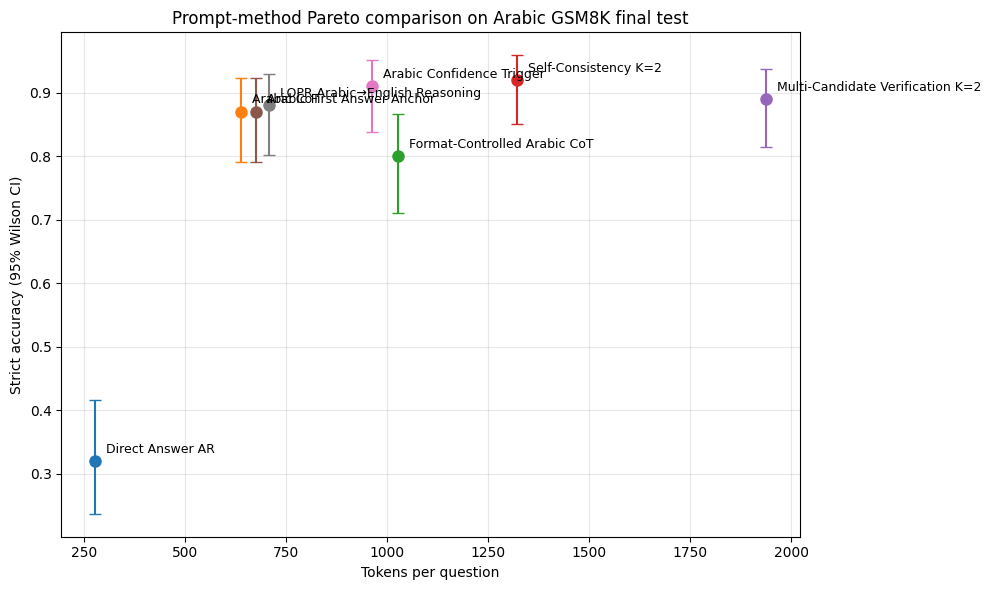

✓ Saved: ./arabic_gsm8k_v5_outputs/methods_pareto.png

CTE CALIBRATION — trusted vs escalated
                    cte_path  n  strict_accuracy  relaxed_accuracy  avg_tokens  avg_calls  avg_fallbacks
escalated_missing_confidence  5           0.4000            0.2000      4821.4        3.0            0.4
                trusted_high 95           0.9368            0.9368       758.7        1.0            0.0
✓ Saved: ./arabic_gsm8k_v5_outputs/cte_calibration.csv

PAIRED STATISTICS VS ARABIC CoT — strict correctness
     baseline                              method  n_common  accuracy_diff_method_minus_cot  bootstrap_ci_low  bootstrap_ci_high  mcnemar_baseline_wrong_method_correct  mcnemar_baseline_correct_method_wrong  mcnemar_exact_p
2. Arabic CoT                 1. Direct Answer AR       100                           -0.55             -0.65              -0.45                                      0                                     55         0.000000
2. Arabic CoT     3. Format-Contro

In [7]:

"""
Final analysis: clean result tables, Pareto plot, CTE calibration,
and paired statistical tests against Arabic CoT.
"""


# ── Reviewer-note coverage checklist ──────────────────────────────
CHECKLIST = [
    ("CTE confidence detection uses strict line regex", "CTE_CONF_RE" in globals()),
    ("Strict and relaxed accuracy are both reported", "Strict_Accuracy" in df_results.columns and "Relaxed_Accuracy" in df_results.columns),
    ("Fallback rate is logged", "Fallback_Rate" in df_results.columns),
    ("K-sweep includes K=1,2,4,8,16", set(K_SWEEP_VALUES) == {1,2,4,8,16}),
    ("Final SC uses K>1", K_SC > 1),
    ("Final Verification uses K>1", K_VERIF > 1),
    ("Validation/final overlap is blocked", True),
    ("Difficulty uses gold solution steps", True),
    ("Raw responses are logged", os.path.exists(ALL_RESPONSES_LOG)),
    ("Failure log is created", os.path.exists(FAILURE_LOG)),
    ("Sample manifest is created", os.path.exists(SAMPLE_MANIFEST_CSV)),
]
print("\n" + "=" * 90)
print("IMPLEMENTATION CHECKLIST — DISCUSSION NOTES")
print("=" * 90)
for note, ok in CHECKLIST:
    print(("✓" if ok else "✗"), note)

# ── Pretty print ──────────────────────────────────────────────────
def fmt_ci(lo, hi):
    return f"[{lo:.3f}, {hi:.3f}]"

print("\n" + "=" * 110)
print("FINAL RESULTS — ARABIC GSM8K — STRICT MAIN METRIC + RELAXED CHECK")
print("=" * 110)
print(f"{'Method':<42} {'Strict':>7} {'CI95':>18} {'Relaxed':>8} {'Tok/Q':>8} {'Calls/Q':>8} {'Fallback%':>11}")
print("-" * 110)
for _, r in df_results.iterrows():
    print(f"{r['Method']:<42} {r['Strict_Accuracy']:>7.3f} "
          f"{fmt_ci(r['Strict_CI_low'], r['Strict_CI_high']):>18} "
          f"{r['Relaxed_Accuracy']:>8.3f} {r['Tokens_per_Q']:>8.0f} "
          f"{r['Avg_Calls']:>8.2f} {r['Fallback_Rate']:>10.2%}")

print("\n" + "=" * 110)
print("STRICT ACCURACY BY GOLD-STEP DIFFICULTY")
print("=" * 110)
print(f"{'Method':<42} {'Easy':>15} {'Medium':>15} {'Hard':>15}")
print("-" * 110)
for _, r in df_results.iterrows():
    print(f"{r['Method']:<42} "
          f"{r['Strict_Easy']:.2f} {fmt_ci(*r['Easy_CI']):>10} "
          f"{r['Strict_Medium']:.2f} {fmt_ci(*r['Medium_CI']):>10} "
          f"{r['Strict_Hard']:.2f} {fmt_ci(*r['Hard_CI']):>10}")

# ── Pareto plot (main evaluation) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for _, r in df_results.iterrows():
    ax.errorbar(r["Tokens_per_Q"], r["Strict_Accuracy"],
                yerr=[[r["Strict_Accuracy"] - r["Strict_CI_low"]], [r["Strict_CI_high"] - r["Strict_Accuracy"]]],
                fmt="o", markersize=8, capsize=4)
    ax.annotate(r["Method"].split(".", 1)[-1].strip(),
                (r["Tokens_per_Q"], r["Strict_Accuracy"]),
                textcoords="offset points", xytext=(8, 6), fontsize=9)
ax.set_xlabel("Tokens per question")
ax.set_ylabel("Strict accuracy (95% Wilson CI)")
ax.set_title("Prompt-method Pareto comparison on Arabic GSM8K final test")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(METHODS_PARETO_PLOT, dpi=150)
plt.show()
print(f"✓ Saved: {METHODS_PARETO_PLOT}")

# ── CTE calibration ───────────────────────────────────────────────
eval_df = pd.DataFrame(EVAL_RECORDS)
cte_df = eval_df[eval_df["method"].str.contains("Confidence Trigger", regex=False)].copy()
if len(cte_df) > 0:
    cal_rows = []
    for path, sub in cte_df.groupby("cte_path", dropna=False):
        cal_rows.append({
            "cte_path": path if isinstance(path, str) else "missing",
            "n": len(sub),
            "strict_accuracy": round(sub["strict_correct"].mean(), 4),
            "relaxed_accuracy": round(sub["relaxed_correct"].mean(), 4),
            "avg_tokens": round(sub["tokens"].mean(), 1),
            "avg_calls": round(sub["calls"].mean(), 2),
            "avg_fallbacks": round(sub["fallbacks"].mean(), 3),
        })
    cte_calibration = pd.DataFrame(cal_rows)
    cte_calibration.to_csv(CTE_CALIBRATION_CSV, index=False)
    print("\n" + "=" * 90)
    print("CTE CALIBRATION — trusted vs escalated")
    print("=" * 90)
    print(cte_calibration.to_string(index=False))
    print(f"✓ Saved: {CTE_CALIBRATION_CSV}")
else:
    print("\nNo CTE records found for calibration.")

# ── Paired statistics against Arabic CoT ──────────────────────────
base_name = "2. Arabic CoT"
if base_name in set(eval_df["method"]):
    pair_rows = []
    base = eval_df[eval_df["method"] == base_name].set_index("problem_id").sort_index()
    for method_name, sub in eval_df.groupby("method"):
        if method_name == base_name:
            continue
        other = sub.set_index("problem_id").sort_index()
        common = sorted(set(base.index) & set(other.index))
        if not common:
            continue
        a = base.loc[common, "strict_correct"].astype(int).tolist()
        b = other.loc[common, "strict_correct"].astype(int).tolist()
        diff, lo, hi = paired_bootstrap_diff(a, b)
        b01, b10, p = mcnemar_exact_p(a, b)
        pair_rows.append({
            "baseline": base_name,
            "method": method_name,
            "n_common": len(common),
            "accuracy_diff_method_minus_cot": round(diff, 4),
            "bootstrap_ci_low": round(lo, 4),
            "bootstrap_ci_high": round(hi, 4),
            "mcnemar_baseline_wrong_method_correct": b01,
            "mcnemar_baseline_correct_method_wrong": b10,
            "mcnemar_exact_p": round(p, 6),
        })
    pairwise_df = pd.DataFrame(pair_rows)
    pairwise_df.to_csv(PAIRWISE_STATS_CSV, index=False)
    print("\n" + "=" * 90)
    print("PAIRED STATISTICS VS ARABIC CoT — strict correctness")
    print("=" * 90)
    print(pairwise_df.to_string(index=False))
    print(f"✓ Saved: {PAIRWISE_STATS_CSV}")
else:
    print("Arabic CoT baseline not found; paired statistics skipped.")

# ── Failure log summary ───────────────────────────────────────────
print("\n" + "=" * 90)
print("FAILURE LOG SUMMARY")
print("=" * 90)
failure_counts = defaultdict(lambda: defaultdict(int))
if os.path.exists(FAILURE_LOG):
    with open(FAILURE_LOG, "r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            failure_counts[rec["method"]]["total"] += 1
            failure_counts[rec["method"]][rec["difficulty"]] += 1
            # Count if any response in the saved response list used fallback.
            if any(r.get("used_fallback") for r in rec.get("responses", [])):
                failure_counts[rec["method"]]["fallback"] += 1

for method, counts in failure_counts.items():
    print(f"  {method:<42} total={counts['total']:>3}  "
          f"E={counts['Easy']:>2} M={counts['Medium']:>2} H={counts['Hard']:>2}  "
          f"fallback-in-any-call={counts['fallback']:>2}")

print(f"\n✓ Full failure responses: {FAILURE_LOG}")
print(f"✓ Full raw response audit log: {ALL_RESPONSES_LOG}")



## Before using numbers in the paper
Use only the output from the locked final-test section for the main result table. The K-sweep section is for choosing/justifying K and for the Pareto/elbow figure only. If Arabic and English versions are matched to the same underlying problems, report the experiment as a paired cross-lingual comparison, not as independent generalization.
